### Colab Activity 21.4: Using a Neural Net for Non-Concentric Data

**Expected Time = 60 minutes** 


This activity focuses on using a neural network to classify a dataset that does not have an obvious linear boundary.  An important idea about the neural net is its ability to solve such problems with high accuracy.  The dataset you will use is created using Scikit-Learn, and is meant to mimic that from the videos.

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)



In [19]:
import warnings

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

warnings.filterwarnings('ignore')

### The Data

Below, a dataset is manufactured to have four centers, and these are then combined to form a binary classification problem.  The data is created and visualized below using the `make_blobs` function.

In [2]:
X, y = make_blobs([50, 50, 50, 50], centers=[[0, 5], [5, 0], [5, 5], [0, 0]],
                  random_state=42)

In [3]:
y[(y == 0) | (y == 1)] = 1
y[(y == 2) | (y == 3)] = 0

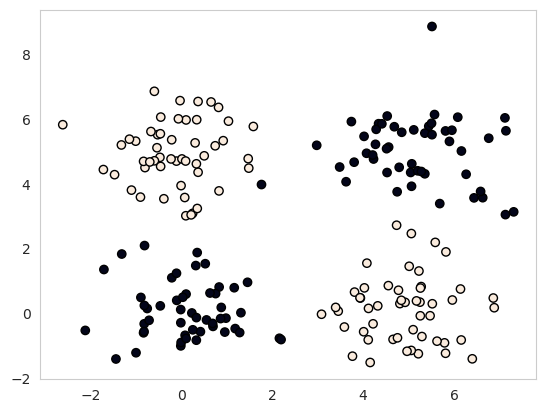

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black')
plt.grid();

[Back to top](#-Index)

### Problem 1

#### The Network Architecture



First, use `keras` to create a `Sequential` model named `model` with a fully connected layer with 100 neurons and a `relu` activation function. The output layer of this model should have one neuron and a `sigmoid` activation function.

Next, compile this model with the `bce` loss and with `metrics` equal to `acc`.

Finally, use the `fit()` method on `model` for training using the `X` and `y` data. For this step, use 100 epochs, set `verbose=0` to disables the output of training progress, and use `validation_split=0.2` to ansure 20% of the data is used for validation. Assign the trained model to the `history` variable below.

In [6]:

model = Sequential([
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(loss='bce', metrics=['acc'])

history = model.fit(X, y, epochs=100, verbose=0, validation_split=0.2)
### ANSWER CHECK
print(history.history['acc'][-1])

I0000 00:00:1757830196.410008  452753 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13020 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1757830198.965461  457795 service.cc:148] XLA service 0x7fadf4003850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757830198.965496  457795 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2025-09-13 23:09:58.981915: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1757830199.015648  457795 cuda_dnn.cc:529] Loaded cuDNN version 91001
I0000 00:00:1757830199.187285  457795 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


0.9750000238418579


[Back to top](#-Index)

### Problem 2

#### How many epochs are necessary



An important consideration is not wasting energy in over training your data.  Create a visualization of the loss function. Can you identify a point of diminishing returns?   

Assign your answer as an integer for what you believe is an optimal number of training  `epochs`. 

In [17]:
epochs = '60'

### ANSWER CHECK
print(epochs)

60


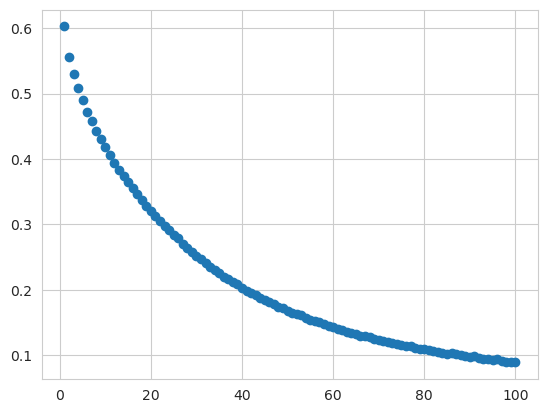

In [21]:
loss = history.history['loss']
epoch_x = range(1, len(loss) + 1)
plt.scatter(epoch_x, loss)

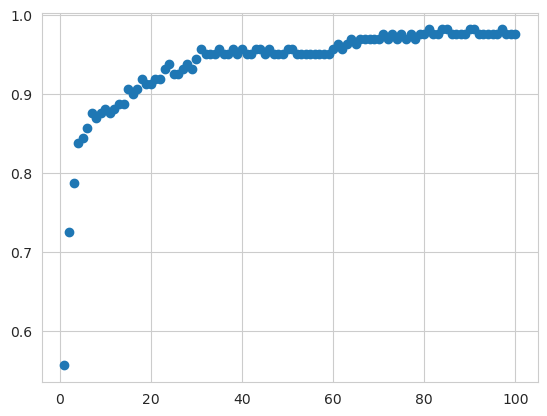

In [22]:
acc = history.history['acc']
epoch_x = range(1, len(acc) + 1)
plt.scatter(epoch_x, acc)

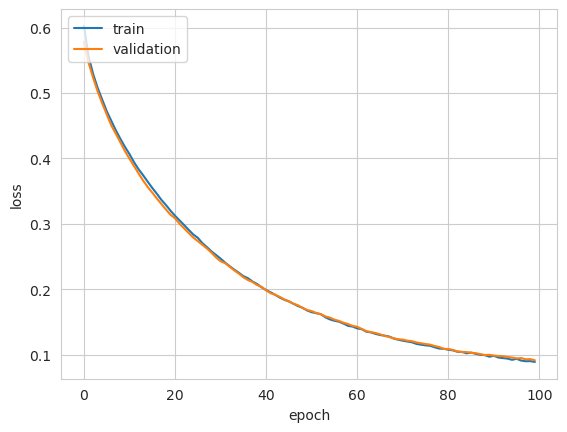

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()